<a href="https://colab.research.google.com/github/irajamuller/error_corrections/blob/main/UA3_UA4_Estabilizadores_Shor_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install qiskit qiskit_aer pylatexenc --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.7 MB/s eta 0:00:00


In [3]:
# Classes do qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator, Aer
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, array_to_latex

import numpy as np

In [101]:
def encode(qc, d):
  qc.barrier(label='Encode')
  # Phase-flip layer
  qc.cx(d[0], d[3])
  qc.cx(d[0], d[6])
  qc.h(d[0])
  qc.h(d[3])
  qc.h(d[6])

  # Bit-flip layers (3 blocos)
  for i in [0, 3, 6]:
    qc.cx(d[i], d[i + 1])
    qc.cx(d[i], d[i + 2])

def logical_x_transversal(qc, d):
  qc.barrier(label='Transversal X_L')
  for i in range(9):
    qc.x(d[i])

def inject_error(qc, d, errors):
  qc.barrier(label="Error")
  if not errors:
      return
  for qubit, etype in errors:
      if etype in ('X', 'Y'):
          qc.x(d[qubit])
      if etype in ('Z', 'Y'):
          qc.z(d[qubit])

def measure_stabilizers_z1_z6(qc, d, a, s0, s1, s2):
    qc.barrier(label='Stabilizers Z1-Z6 (bit-flip)')
    for i in range(6):
        qc.reset(a[i])

    # Bloco 0
    qc.h(a[0])
    qc.cz(d[0], a[0])
    qc.cz(d[1], a[0])
    qc.h(a[0])   # mede Z0 Z1

    qc.h(a[1])
    qc.cz(d[1], a[1])
    qc.cz(d[2], a[1])
    qc.h(a[1])   # mede Z1 Z2

    # Bloco 1
    qc.h(a[2])
    qc.cz(d[3], a[2])
    qc.cz(d[4], a[2])
    qc.h(a[2])

    qc.h(a[3])
    qc.cz(d[4], a[3])
    qc.cz(d[5], a[3])
    qc.h(a[3])

    # Bloco 2
    qc.h(a[4])
    qc.cz(d[6], a[4])
    qc.cz(d[7], a[4])
    qc.h(a[4])

    qc.h(a[5])
    qc.cz(d[7], a[5])
    qc.cz(d[8], a[5])
    qc.h(a[5])

    qc.measure(a[0], s0[0])
    qc.measure(a[1], s0[1])
    qc.measure(a[2], s1[0])
    qc.measure(a[3], s1[1])
    qc.measure(a[4], s2[0])
    qc.measure(a[5], s2[1])

def measure_stabilizers_z7_z8(qc, d, a, sz):
    qc.barrier(label='Stabilizers Z7-Z8 (phase-flip)')
    qc.reset(a[0])
    qc.reset(a[1])

    # Z7: X0X1X2X3X4X5  →  paridade entre bloco 0 e 1
    qc.h(a[0])
    for i in [0,1,2,3,4,5]:
        qc.h(d[i])      # muda para base Z
        qc.cz(a[0], d[i])
        qc.h(d[i])      # volta
    qc.h(a[0])
    qc.measure(a[0], sz[0])

    # Z8: X3X4X5X6X7X8  →  paridade entre bloco 1 e 2
    qc.h(a[1])
    for i in [3,4,5,6,7,8]:
        qc.h(d[i])
        qc.cz(a[1], d[i])
        qc.h(d[i])
    qc.h(a[1])
    qc.measure(a[1], sz[1])

def correct_x(qc, d, s0, s1, s2):
  qc.barrier(label='Correction X')
  # Bloco 0
  with qc.if_test((s0, 0b01)): qc.x(d[0])
  with qc.if_test((s0, 0b11)): qc.x(d[1])
  with qc.if_test((s0, 0b10)): qc.x(d[2])
  # Bloco 1
  with qc.if_test((s1, 0b01)): qc.x(d[3])
  with qc.if_test((s1, 0b11)): qc.x(d[4])
  with qc.if_test((s1, 0b10)): qc.x(d[5])
  # Bloco 2
  with qc.if_test((s2, 0b01)): qc.x(d[6])
  with qc.if_test((s2, 0b11)): qc.x(d[7])
  with qc.if_test((s2, 0b10)): qc.x(d[8])

def correct_z(qc, d, sz):
  qc.barrier(label='Correction Z')

  with qc.if_test((sz, 0b01)): qc.z(d[0])  # bloco 0
  with qc.if_test((sz, 0b11)): qc.z(d[3])  # bloco 1
  with qc.if_test((sz, 0b10)): qc.z(d[6])  # bloco 2

def decode(qc, d):
  qc.barrier(label='Decode')
  for i in [0, 3, 6]:
    qc.cx(d[i], d[i + 1])              # desfaz cópia 1
    qc.cx(d[i], d[i + 2])              # desfaz cópia 2

  # Inverte Hadamard
  qc.h(d[0]); qc.h(d[3]); qc.h(d[6])

  qc.cx(d[0], d[3])
  qc.cx(d[0], d[6])
  qc.ccx(d[3], d[6], d[0])   # Toffoli: voto majoritário phase-flip

def create_circuit(psi, errors):
  q_codes = QuantumRegister(9, 'code')

  q_ancilla_x = QuantumRegister(6, 'ancilla_x')
  q_ancilla_z = QuantumRegister(2, 'ancilla_z')

  c_syndromes0 = ClassicalRegister(2, name='syndrom b0')   # síndrome bloco 0
  c_syndromes1 = ClassicalRegister(2, name='syndrom b1')   # síndrome bloco 1
  c_syndromes2 = ClassicalRegister(2, name='syndrom b2')   # síndrome bloco 2
  c_syndromes_z = ClassicalRegister(2, name='syndrom z')   # síndrome Z

  logical_bit = ClassicalRegister(1, 'logical bit')

  qc = QuantumCircuit(q_codes, q_ancilla_x, q_ancilla_z, c_syndromes0, c_syndromes1, c_syndromes2, c_syndromes_z, logical_bit)
  qc.barrier(label="Initial state")

  # Troca estado inicial de |0> para |1>
  if psi != '0': qc.x(q_codes[0])

  # Encode
  encode(qc, q_codes)

  # Transversal
  logical_x_transversal(qc, q_codes)

  # Inject Error
  inject_error(qc, q_codes, errors)

  # Measure, and correction X errors
  measure_stabilizers_z1_z6(qc, q_codes, q_ancilla_x, c_syndromes0, c_syndromes1, c_syndromes2)
  measure_stabilizers_z7_z8(qc, q_codes, q_ancilla_z, c_syndromes_z)

  correct_x(qc, q_codes, c_syndromes0, c_syndromes1, c_syndromes2)
  correct_z(qc, q_codes, c_syndromes_z)

  # Decode
  decode(qc, q_codes)

  qc.barrier(label='fim')
  qc.measure(q_codes[0], logical_bit[0])

  return qc

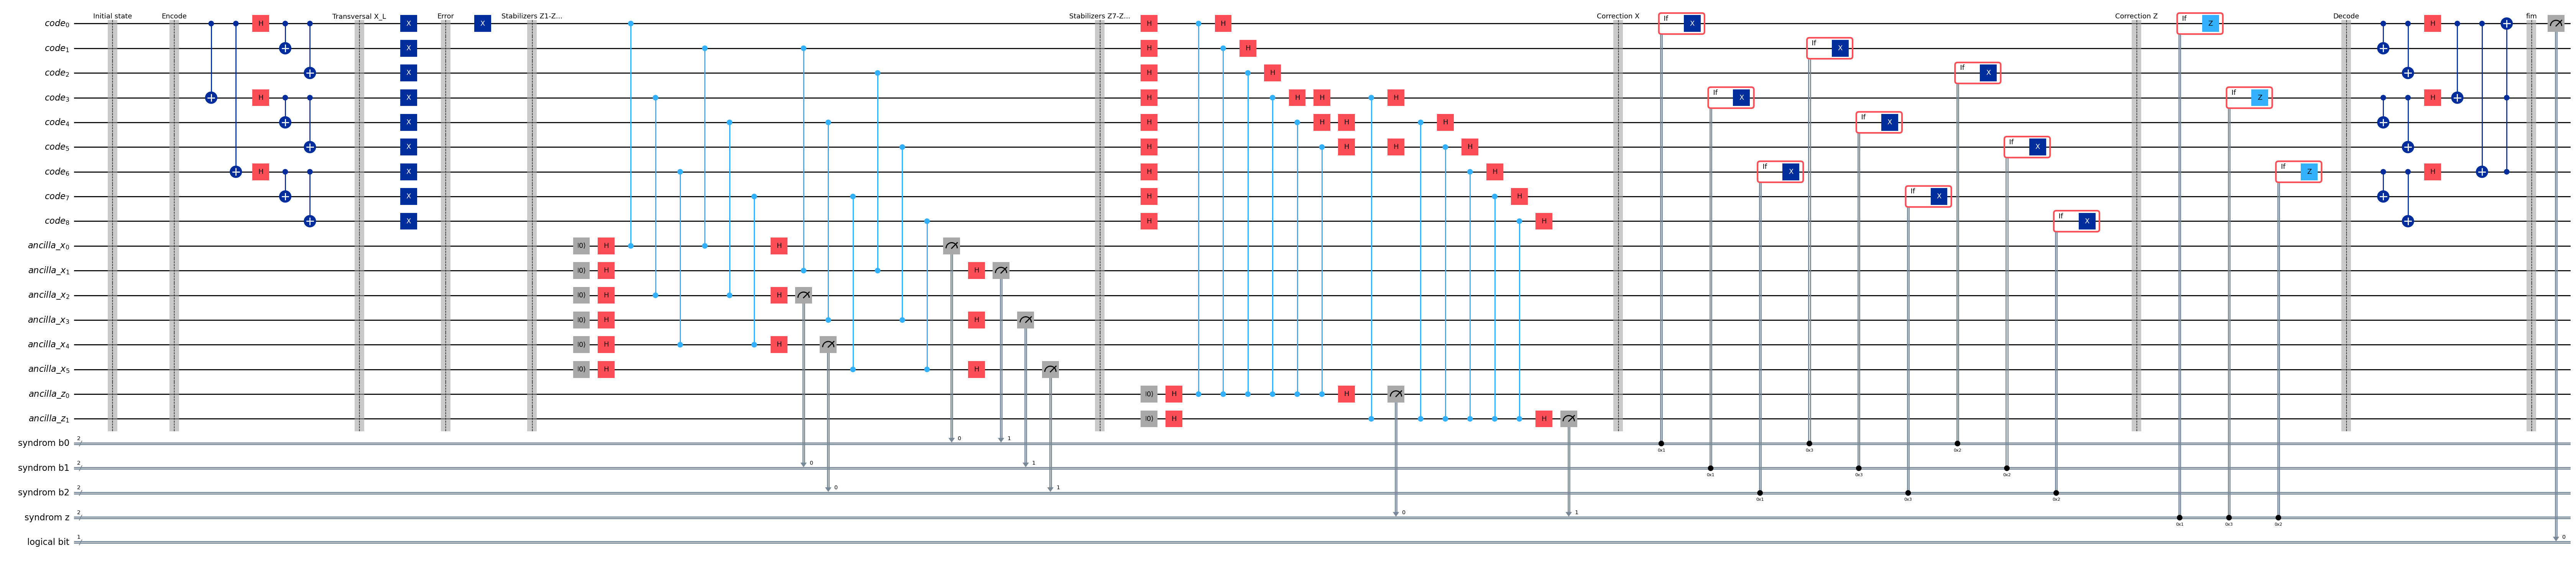

In [99]:
qc = create_circuit('0', [(0, 'X')])
qc.draw('mpl', fold=-1)

In [102]:
def analyze_errors(errors):
  if not errors:
      return {'correctable': True, 'reason': 'sem erros',
              'block_x_count': {}, 'z_count': 0}

  # Colapsa X+Z no mesmo qubit → Y (representação canônica)
  from collections import defaultdict
  qubit_types: dict[int, set] = defaultdict(set)
  for qubit, etype in errors:
      for component in ('X', 'Z') if etype == 'Y' else [etype]:
          qubit_types[qubit].add(component)

  # Reconstrói lista canônica: nunca haverá duplicatas agora
  canonical = []
  for qubit, components in qubit_types.items():
      if components == {'X', 'Z'}:
          canonical.append((qubit, 'Y'))
      elif components == {'X'}:
          canonical.append((qubit, 'X'))
      elif components == {'Z'}:
          canonical.append((qubit, 'Z'))
      else:
          # X+X ou Z+Z se cancelam — erro nulo neste qubit
          pass  # não adiciona: efeito líquido é identidade

  # A partir daqui, usa `canonical` no lugar de `errors`
  block_x: dict[int, int] = {0: 0, 1: 0, 2: 0}
  block_z: set[int] = set()

  for qubit, etype in canonical:
      block = qubit // 3
      if etype in ('X', 'Y'):
          block_x[block] += 1
      if etype in ('Z', 'Y'):
          block_z.add(block)

  # Regra 1: no máximo 1 erro X por bloco
  for b, cnt in block_x.items():
      if cnt > 1:
          return {
              'correctable': False,
              'reason': (f'{cnt} erros X no bloco {b} '
                          f'[d{b*3}..d{b*3+2}] — síndrome ambígua'),
              'block_x_count': block_x,
              'z_count': len(block_z)
          }

  # Regra 2: no máximo 1 bloco com erro Z
  if len(block_z) > 1:
      return {
          'correctable': False,
          'reason': (f'erros Z em {len(block_z)} blocos diferentes '
                      f'{sorted(block_z)} — voto majoritário enganado'),
          'block_x_count': block_x,
          'z_count': len(block_z)
      }

  return {
      'correctable': True,
      'reason': 'dentro da capacidade do código',
      'block_x_count': block_x,
      'z_count': len(block_z)
  }

def run_experiment(initial_state='0', errors=None, shots=10):
  errors = errors or []
  analysis = analyze_errors(errors)
  qc = create_circuit(initial_state, errors)

  backend = AerSimulator(method='statevector')
  qc_t = transpile(qc, backend=backend)

  result = backend.run(qc_t, shots=shots).result()
  counts = result.get_counts()
  print("  COUNTS:", counts)

  # O dicionário 'recovered' agora armazena a string completa
  recovered: dict[str, int] = {}
  for bitstring, cnt in counts.items():
      bit_logico = bitstring.split()[0]
      recovered[bit_logico] = recovered.get(bit_logico, 0) + cnt

  W = 62
  print(f"  Estado inicial        : |{initial_state}⟩")
  if errors:
      for q, t in sorted(errors):
          bloco = q // 3
          print(f"  Erro                  : {t:1s} em d[{q}]  (bloco {bloco})")
  else:
      print(f"  Erros                 : nenhum (canal ideal)")

  print(f"  Corrigível?           : {'✓ SIM' if analysis['correctable'] else '✗ NÃO'} — {analysis['reason']}")
  print(f"  Shots                 : {shots}")
  print('─' * W)

  # Exibição: Bit lógico (extraído da string) + String completa
  for bitstring, cnt in sorted(recovered.items()):
      pct = 100 * cnt / shots
      bit_logico = bitstring.split()[0]
      print(f"  |{bit_logico}⟩ -> |{bitstring}⟩ {'':<10} {pct:5.1f}%")

  dominant_full = max(recovered, key=recovered.get)
  dominant_logico = dominant_full.split()[0]
  ok = (dominant_logico == initial_state)

  print('─' * W)
  print(f"  Resultado             : |{dominant_logico}⟩ (String: {dominant_full})  "
        f"{'✓ CORRETO' if ok else '✗ FALHOU'}")
  print('═' * W)

In [103]:
# Cenários
W = 64
# Grupo 1 — Erros Um único erro (todos corrigíveis)
print("\n" + "━" * W)
print("  Grupo 1 — Erros Um único erro (todos corrigíveis)")
print("━" * W)
errors_grupo1 = [
    ('0', [(3, 'X')]),
    ('0', [(4, 'X')]),
    ('0', [(5, 'X')]),
    ('1', [(3, 'X')]),
    ('0', [(0, 'Z')]),
    ('0', [(3, 'Z')]),
    ('0', [(6, 'Z')]),
    ('0', [(3, 'Y')]),
    ('0', [(4, 'Y')]),
    ('0', [(5, 'Y')]),
]
for initial_state, error in errors_grupo1:
  run_experiment(initial_state, error)



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Grupo 1 — Erros Um único erro (todos corrigíveis)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  COUNTS: {'0 00 00 01 00': 10}
  Estado inicial        : |0⟩
  Erro                  : X em d[3]  (bloco 1)
  Corrigível?           : ✓ SIM — dentro da capacidade do código
  Shots                 : 10
──────────────────────────────────────────────────────────────
  |0⟩ -> |0⟩            100.0%
──────────────────────────────────────────────────────────────
  Resultado             : |0⟩ (String: 0)  ✓ CORRETO
══════════════════════════════════════════════════════════════
  COUNTS: {'0 00 00 11 00': 10}
  Estado inicial        : |0⟩
  Erro                  : X em d[4]  (bloco 1)
  Corrigível?           : ✓ SIM — dentro da capacidade do código
  Shots                 : 10
──────────────────────────────────────────────────────────────
  |0⟩ -> |0⟩            100.0%
────────────────────────────────────────────